<a href="https://colab.research.google.com/github/ayrous02/YSP_2025/blob/main/slider_tester_interactive_visuaization_for_complex_metricsipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

#Equatons




---
##nSPS calculation

In [ ]:
#
from rdkit import Chem
import rdkit.Chem.Descriptors as Desc
import numpy as np

class SpacialScore:
    """Class for calculating the spacial score (SPS) and size-normalized SPS (nSPS) for small organic molecules"""
    def __init__(self, mol):
        self.mol = mol

        self.hyb_score = {}
        self.stereo_score = {}
        self.ring_score = {}
        self.bond_score = {}
        self.chiral_idxs = self.find_stereo_atom_idxs()
        self.doublebonds_stereo = self.find_doublebonds_stereo()
        self.score = self.calculate_spacial_score()
        self.per_atom_score = self.score / Desc.HeavyAtomCount(self.mol) if Desc.HeavyAtomCount(self.mol) > 0 else np.nan

    def find_stereo_atom_idxs(self):
        """Finds indices of atoms that are (pseudo)stereo/chiral centers"""
        stereo_centers = Chem.FindMolChiralCenters(self.mol, includeUnassigned=True, includeCIP=False, useLegacyImplementation=False)
        return [atom_idx for atom_idx, _ in stereo_centers]

    def find_doublebonds_stereo(self):
        """Finds indices of stereo double bond atoms (E/Z)"""
        return {(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()): bond.GetStereo()
                for bond in self.mol.GetBonds() if bond.GetBondType() == Chem.rdchem.BondType.DOUBLE}

    def calculate_spacial_score(self):
        """Calculates the total spacial score for a molecule"""
        score = 0
        for atom in self.mol.GetAtoms():
            atom_idx = atom.GetIdx()
            self.hyb_score[atom_idx] = self._account_for_hybridisation(atom)
            self.stereo_score[atom_idx] = self._account_for_stereo(atom_idx)
            self.ring_score[atom_idx] = self._account_for_ring(atom)
            self.bond_score[atom_idx] = self._account_for_neighbours(atom)
            score += self._calculate_score_for_atom(atom_idx)
        return score

    def _calculate_score_for_atom(self, atom_idx):
        """Calculates the total score for a single atom in a molecule"""
        return (self.hyb_score[atom_idx] * self.stereo_score[atom_idx] *
                self.ring_score[atom_idx] * self.bond_score[atom_idx])

    def _account_for_hybridisation(self, atom):
        """Calculates the hybridisation score for a single atom in a molecule"""
        hybridisations = {"SP": 1, "SP2": 2, "SP3": 3}
        return hybridisations.get(str(atom.GetHybridization()), 4)

    def _account_for_stereo(self, atom_idx):
        """Calculates the stereo score for a single atom in a molecule"""
        if atom_idx in self.chiral_idxs:
            return 2
        if any(atom_idx in bond_atom_idxs and str(stereo) != "STEREONONE" for bond_atom_idxs, stereo in self.doublebonds_stereo.items()):
            return 2
        return 1

    def _account_for_ring(self, atom):
        """Calculates the ring score for a single atom in a molecule"""
        return 1 if atom.GetIsAromatic() else 2 if atom.IsInRing() else 1

    def _account_for_neighbours(self, atom):
        """Calculates the neighbor score for a single atom in a molecule"""
        return len(atom.GetNeighbors()) ** 2

def calculate_spacial_scores(mol):
    """Returns both SPS (total score) and nSPS (normalized)"""
    if mol is None:
        return np.nan, np.nan
    score_obj = SpacialScore(mol)
    return score_obj.score, score_obj.per_atom_score

bioticMolecules_snSPSMetrics = {}
abioticMolecules_snSPSMetrics = {}

for aa, smiles in aasmiles.items():
    mol = Chem.MolFromSmiles(smiles)
    sps_val, nsps_val = calculate_spacial_scores(mol)
    bioticMolecules_snSPSMetrics[aa] = {
        "SPS": sps_val,
        "nSPS": nsps_val
    }
    print(f"{aa}: SPS = {sps_val:.3f}, nSPS = {nsps_val:.3f}")

print("\n--- ABIÓTICAS ---\n")

# ✅ Abióticas – novo loop correto
for classMol, molecules in abiotic_molecules.items():
    for name, smiles in molecules.items():
        mol = Chem.MolFromSmiles(smiles)
        sps_val, nsps_val = calculate_spacial_scores(mol)
        abioticMolecules_snSPSMetrics[f"{classMol} | {name}"] = {
            "SPS": sps_val,
            "nSPS": nsps_val
        }
        print(f"{classMol} | {name}: SPS = {sps_val:.3f}, nSPS = {nsps_val:.3f}")

NameError: name 'aasmiles' is not defined

# Plot for Changing Parameters (carbon)

In [ ]:
#chatgpt assist for # of carbons input

In [ ]:
def generate_linear_alkane(num_carbons):
    """
    Generate a linear alkane (e.g., methane, ethane, propane, etc.)
    """
    if num_carbons < 1:
        raise ValueError("Number of carbon atoms must be at least 1")
    smiles = "C" * num_carbons  # e.g., "CCCC" for butane
    mol = Chem.MolFromSmiles(smiles)
    return mol

In [ ]:
x_vals = np.arange(0,10,1)
y_vals = []
for n_carbons in range(1, 11):
    mol = generate_linear_alkane(n_carbons)
    sps_val, nsps_val = calculate_spacial_scores(mol)
    y_vals.append(nsps_val)
    print(f"Alkane with {n_carbons} C atoms: SPS = {sps_val:.3f}, nSPS = {nsps_val:.3f}")

Alkane with 1 C atoms: SPS = 0.000, nSPS = 0.000
Alkane with 2 C atoms: SPS = 6.000, nSPS = 3.000
Alkane with 3 C atoms: SPS = 18.000, nSPS = 6.000
Alkane with 4 C atoms: SPS = 30.000, nSPS = 7.500
Alkane with 5 C atoms: SPS = 42.000, nSPS = 8.400
Alkane with 6 C atoms: SPS = 54.000, nSPS = 9.000
Alkane with 7 C atoms: SPS = 66.000, nSPS = 9.429
Alkane with 8 C atoms: SPS = 78.000, nSPS = 9.750
Alkane with 9 C atoms: SPS = 90.000, nSPS = 10.000
Alkane with 10 C atoms: SPS = 102.000, nSPS = 10.200


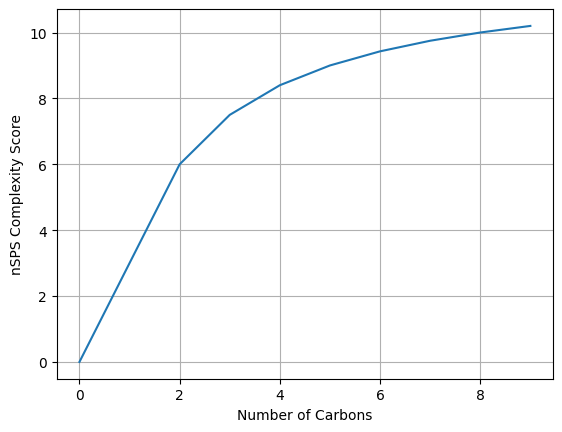

In [ ]:
plt.plot(x_vals, y_vals)
plt.xlabel("Number of Carbons")
plt.ylabel("nSPS Complexity Score")
plt.grid()

In [ ]:
from rdkit import Chem
import numpy as np

def generate_linear_alkane(num_carbons):
    """
    Generate a linear alkane (e.g., methane, ethane, propane, etc.)
    """
    if num_carbons < 1:
        raise ValueError("Number of carbon atoms must be at least 1")
    smiles = "C" * num_carbons
    mol = Chem.MolFromSmiles(smiles)
    return mol

def awc_count(walk, atom):
    if walk == 1:
        return atom.GetDegree()
    else:
        count = 0
        for neigh in atom.GetNeighbors():
            count += awc_count(walk - 1, neigh)
        return count

def twc(mol):
    awc = np.zeros((mol.GetNumAtoms(), mol.GetNumAtoms() - 1))
    for atom_num, atom in enumerate(mol.GetAtoms()):
        for walk in range(1, mol.GetNumAtoms()):
            awc[atom_num][walk - 1] = awc_count(walk, atom)
    mwc_count = np.sum(awc, axis=0)
    amwc_count = np.sum(awc, axis=1)
    twc_count = np.sum(mwc_count)
    amwc_sym_count = sum(set(amwc_count))  # WCX
    return twc_count, amwc_sym_count

# Use numerical input instead of SMILES dictionaries
wcx_y_vals = []
print("\nLinear Alkanes (WCX metric):")
for n_carbons in range(1, 11):  # methane to decane
    mol = generate_linear_alkane(n_carbons)
    twc_val, wcx_val = twc(mol)
    wcx_y_vals.append(wcx_val)
    print(f"Alkane with {n_carbons} C atoms: WCX = {wcx_val:.0f}")


Linear Alkanes (WCX metric):
Alkane with 1 C atoms: WCX = 0
Alkane with 2 C atoms: WCX = 1
Alkane with 3 C atoms: WCX = 7
Alkane with 4 C atoms: WCX = 16
Alkane with 5 C atoms: WCX = 56
Alkane with 6 C atoms: WCX = 111
Alkane with 7 C atoms: WCX = 320
Alkane with 8 C atoms: WCX = 627
Alkane with 9 C atoms: WCX = 1664
Alkane with 10 C atoms: WCX = 3250


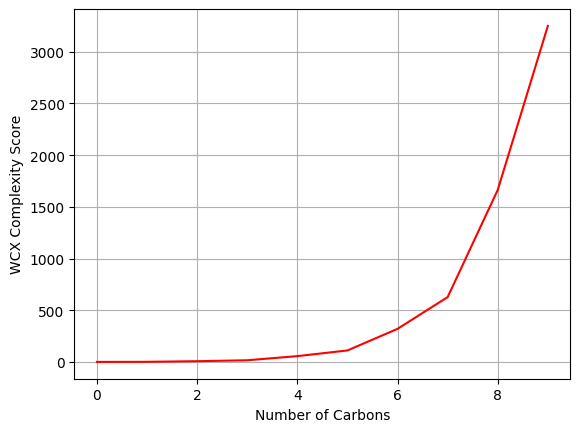

In [ ]:
plt.plot(x_vals, wcx_y_vals, color='red')
plt.xlabel("Number of Carbons")
plt.ylabel("WCX Complexity Score")
plt.grid()

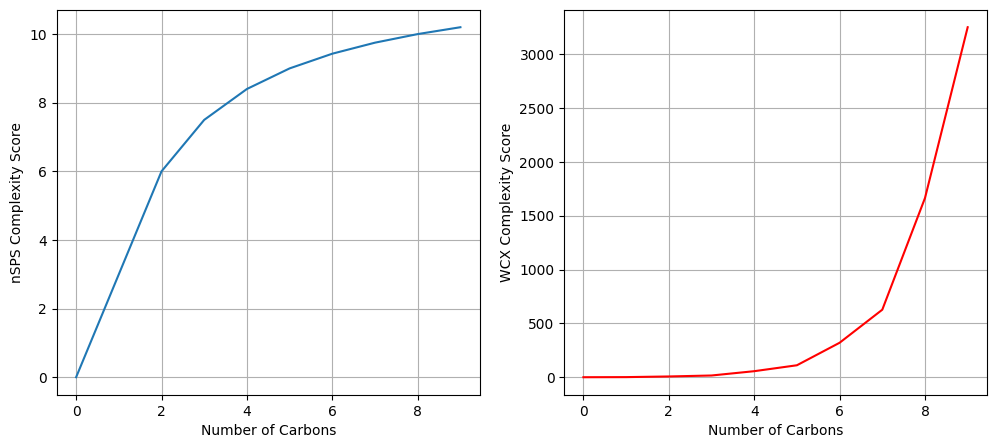

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].plot(x_vals, y_vals)
axs[0].set_xlabel("Number of Carbons")
axs[0].set_ylabel("nSPS Complexity Score")
axs[0].grid()
axs[1].plot(x_vals, wcx_y_vals, color='red') #log scale for yvals?
axs[1].set_xlabel("Number of Carbons")
axs[1].set_ylabel("WCX Complexity Score")
axs[1].grid()



---


#Slider
*on progress*

In [ ]:
pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 52.5 MB/s eta 0:00:00


In [ ]:
pip install py3Dmol

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import ipywidgets as widgets
import tempfile
import os

def desenha_molecula(smiles):
    plt.close('all')
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print("SMILES inválido.")
        return

    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol)
    AllChem.UFFOptimizeMolecule(mol)

    temp = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
    Draw.MolToFile(mol, size=(300, 300), filename=temp.name)

    img = mpimg.imread(temp.name)
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Molécula: {smiles}")
    plt.show()
    os.remove(temp.name)


entrada_smiles = widgets.Text(
    value='CCO',
    placeholder='Digite um SMILES, ex: CCO',
    description='SMILES:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='60%')
)


saida = widgets.interactive_output(desenha_molecula, {'smiles': entrada_smiles})
display(widgets.VBox([entrada_smiles, saida]))


In [ ]:
%matplotlib inline
from ipywidgets import interactive
import matplotlib.pyplot as plt
import numpy as np


#
from rdkit import Chem
import rdkit.Chem.Descriptors as Desc
import numpy as np

class SpacialScore:
    """Class for calculating the spacial score (SPS) and size-normalized SPS (nSPS) for small organic molecules"""
    def __init__(self, mol):
        self.mol = mol

        self.hyb_score = {}
        self.stereo_score = {}
        self.ring_score = {}
        self.bond_score = {}
        self.chiral_idxs = self.find_stereo_atom_idxs()
        self.doublebonds_stereo = self.find_doublebonds_stereo()
        self.score = self.calculate_spacial_score()
        self.per_atom_score = self.score / Desc.HeavyAtomCount(self.mol) if Desc.HeavyAtomCount(self.mol) > 0 else np.nan

    def find_stereo_atom_idxs(self):
        """Finds indices of atoms that are (pseudo)stereo/chiral centers"""
        stereo_centers = Chem.FindMolChiralCenters(self.mol, includeUnassigned=True, includeCIP=False, useLegacyImplementation=False)
        return [atom_idx for atom_idx, _ in stereo_centers]

    def find_doublebonds_stereo(self):
        """Finds indices of stereo double bond atoms (E/Z)"""
        return {(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()): bond.GetStereo()
                for bond in self.mol.GetBonds() if bond.GetBondType() == Chem.rdchem.BondType.DOUBLE}

    def calculate_spacial_score(self):
        """Calculates the total spacial score for a molecule"""
        score = 0
        for atom in self.mol.GetAtoms():
            atom_idx = atom.GetIdx()
            self.hyb_score[atom_idx] = self._account_for_hybridisation(atom)
            self.stereo_score[atom_idx] = self._account_for_stereo(atom_idx)
            self.ring_score[atom_idx] = self._account_for_ring(atom)
            self.bond_score[atom_idx] = self._account_for_neighbours(atom)
            score += self._calculate_score_for_atom(atom_idx)
        return score

    def _calculate_score_for_atom(self, atom_idx):
        """Calculates the total score for a single atom in a molecule"""
        return (self.hyb_score[atom_idx] * self.stereo_score[atom_idx] *
                self.ring_score[atom_idx] * self.bond_score[atom_idx])

    def _account_for_hybridisation(self, atom):
        """Calculates the hybridisation score for a single atom in a molecule"""
        hybridisations = {"SP": 1, "SP2": 2, "SP3": 3}
        return hybridisations.get(str(atom.GetHybridization()), 4)

    def _account_for_stereo(self, atom_idx):
        """Calculates the stereo score for a single atom in a molecule"""
        if atom_idx in self.chiral_idxs:
            return 2
        if any(atom_idx in bond_atom_idxs and str(stereo) != "STEREONONE" for bond_atom_idxs, stereo in self.doublebonds_stereo.items()):
            return 2
        return 1

    def _account_for_ring(self, atom):
        """Calculates the ring score for a single atom in a molecule"""
        return 1 if atom.GetIsAromatic() else 2 if atom.IsInRing() else 1

    def _account_for_neighbours(self, atom):
        """Calculates the neighbor score for a single atom in a molecule"""
        return len(atom.GetNeighbors()) ** 2

def calculate_spacial_scores(mol):
    """Returns both SPS (total score) and nSPS (normalized)"""
    if mol is None:
        return np.nan, np.nan
    score_obj = SpacialScore(mol)
    return score_obj.score, score_obj.per_atom_score

input_smiles = entrada_smiles

dropdown_metrica = widgets.Dropdown(
    options=["SPS", "nSPS"],
    description='Escolha a métrica:',
    layout=widgets.Layout(width='50%'),
    style={'description_width': 'initial'}
)

output_plot = widgets.Output()

def atualizar_plot(smiles, metrica):
    output_plot.clear_output(wait=True)
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        with output_plot:
            print("SMILES inválido.")
        return

    sps, nsps = calculate_spacial_scores(mol)
    valor = sps if metrica == "SPS" else nsps

    with output_plot:
        plt.figure(figsize=(5, 3))
        plt.bar([metrica], [valor], color='orange')
        plt.ylim(0, max(10, valor + 2))
        plt.title(f"{metrica} para a molécula")
        plt.ylabel("Valor")
        plt.grid(True)
        plt.show()


ui = widgets.VBox([input_smiles, dropdown_metrica])
out = widgets.interactive_output(atualizar_plot, {'smiles': input_smiles, 'metrica': dropdown_metrica})

display(ui, output_plot, out)

#def f(carbons, chiralC):
 #   plt.figure(2)
  #  x = np.linspace(-10, 10, num=1000)
   # plt.plot(x, carbons * x + chiralC)
    #plt.ylim(-5, 5)
   # plt.show() # This is part that needs to be added to fix the issue

#interactive_plot = interactive(f, carbons=(1, 20), chiralC=(0, 100))
#output = interactive_plot.children[-1]
#output.layout.height = '350px'
#interactive_plot

Output()

Output()

In [ ]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, clear_output

carbons_slider = widgets.IntSlider(value=6, min=1, max=30, description="Carbons:")
walk_length_slider = widgets.IntSlider(value=3, min=1, max=6, description="Max Walk l:")
grau_medio_slider = widgets.IntSlider(value=2, min=1, max=4, description="Grau médio:")

chiral_slider = widgets.IntSlider(value=1, min=0, max=10, description="C. quirais:")
double_bond_slider = widgets.IntSlider(value=1, min=0, max=10, description="Double bond:")
ring_slider = widgets.IntSlider(value=1, min=0, max=10, description="Rings:")

dropdown_metric = widgets.Dropdown(
    options=["nSPS", "Other (estimated)"],
    value="nSPS",
    description="Metric:"
)

output_plot = widgets.Output()

#edit to align with true equation

def estimar_complexidade(carbons, chiralC, doubleB, rings, metrica):
    output_plot.clear_output(wait=True)

    if metrica == "nSPS":
        valor = (carbons * 0.5 + chiralC * 2 + doubleB + rings * 1.5) / carbons
    elif metrica == "Other (estimado)":
        valor = (carbons * 0.8 + chiralC * 3 + doubleB * 2 + rings * 2.5)
    else:
        valor = 0

    with output_plot:
        plt.figure(figsize=(5, 3))
        plt.bar([metrica], [valor], color='purple')
        plt.title(f"{metrica} estimated: {valor}")
        plt.ylabel("Estimated value")
        plt.ylim(0, max(10, valor + 2))
        plt.grid(True)
        plt.show()

ui = widgets.VBox([
    carbons_slider,
    chiral_slider,
    double_bond_slider,
    ring_slider,
    dropdown_metric
])

interactive_out = widgets.interactive_output(
    estimar_complexidade,
    {
        'carbons': carbons_slider,
        'chiralC': chiral_slider,
        'doubleB': double_bond_slider,
        'rings': ring_slider,
        'metrica': dropdown_metric
    }
)

display(ui, output_plot, interactive_out)


Output()

Output()

###WCX

In [ ]:
from rdkit import Chem
import numpy as np

def awc_count(walk,atom):
    if walk == 1:
        return atom.GetDegree()
    else:
        count = 0
        for neigh in atom.GetNeighbors():
            count += awc_count(walk-1, neigh)
        return count

def twc(mol):
    awc = np.zeros((mol.GetNumAtoms(), mol.GetNumAtoms()-1))
    for atom_num, atom in enumerate(mol.GetAtoms()):
        for walk in range(1,mol.GetNumAtoms()):
            awc[atom_num][walk-1] = awc_count(walk,atom)
    mwc_count =  np.sum(awc, axis = 0)
    amwc_count =  np.sum(awc, axis = 1)
    twc_count = np.sum(mwc_count)
    amwc_sym_count = sum(set(amwc_count))
    return twc_count, amwc_sym_count


In [ ]:
import ipywidgets as widgets
from IPython.display import display
from rdkit import Chem

def generate_linear_chain(n):
    return Chem.MolFromSmiles("C" * n)

def generate_branched_chain(n):
    if n < 4:
        return Chem.MolFromSmiles("C" * n)
    return Chem.MolFromSmiles("CC(C)(C)" + "C"*(n-4))

@widgets.interact(n_atoms=(3, 15), ramificada=[False, True])
def calcula_wcx(n_atoms=6, ramificada=False):
    mol = generate_branched_chain(n_atoms) if ramificada else generate_linear_chain(n_atoms)
    Chem.Draw.MolToImage(mol)
    wcx_val = twc(mol)[1]
 #wcx_val = twc(mol)
    _, nsps_val = calculate_spacial_scores(mol)

    print(f"WCX: {wcx_val:.0f}")
    print(f"nSPS: {nsps_val:.2f}")
    display(Chem.Draw.MolToImage(mol, size=(300,300)))

    metrics = [wcx_val, nsps_val]
    labels = ['WCX', 'nSPS']
    colors = ['purple', 'green']

    plt.figure(figsize=(6, 4))
    plt.bar(labels, metrics, color=colors)
    plt.title(f"Molecular complexity for {n_atoms} carbons")
    plt.ylabel("Metric's value")
    plt.ylim(0, max(metrics) + 5)
    plt.grid(axis='y')
    plt.show()

    #print(f"WCX: {wcx_val:.0f}")
    #display(Chem.Draw.MolToImage(mol))
    #plt.figure(figsize=(5, 3))
    #plt.bar(["WCX"], [wcx_val], color='purple')
    #plt.title(f"WCX estimated: {wcx_val}")
    #plt.ylabel("Estimated value")
    #plt.ylim(0, max(10, wcx_val + 2))
    #plt.grid(True)
    #plt.show()


interactive(children=(IntSlider(value=6, description='n_atoms', max=15, min=3), Dropdown(description='ramifica…